# Deep-Learning Assisted Eigenmode Retrieval

We attempt to make predictions on subsequent turbulence eigenmodes with the help of deep learning. We use a Fourier Neural Operator, which is well suited to learn nonlinear functions which applies transformations in the fourier domain.

In [106]:
import torch
import torch.nn as nn
import os
import numpy as np
from torch.utils.data import DataLoader, TensorDataset
import torch.nn.functional as F
from torch.optim import Adam
import matplotlib.pyplot as plt
from LightPipes import *

import fno
from fno import FNO2d, spectral_relative_l2, make_freq_weights, overlap_loss

# Begin by loading up the dataset

Alternatively, load from a pre-converted `.npz` file (much faster — run `convert_dataset_to_npz.py` first).

In [107]:

NPZ_PATH = "datasets/dataset2.npz"   # ← path to the pre-converted .npz file

npz = np.load(NPZ_PATH)
data = {k: npz[k] for k in npz.files}

print(f"Loaded dataset from '{NPZ_PATH}'")
print(f"Keys    : {list(data.keys())}")
print(f"Samples : {data['gaussian_forward_real'].shape[0]}")
print(f"Grid    : {data['gaussian_forward_real'].shape[1:]} (H x W)")


Loaded dataset from 'datasets/dataset2.npz'
Keys    : ['eigenmode_1_real', 'eigenmode_2_real', 'eigenmode_3_real', 'eigenmode_4_real', 'eigenmode_1_imag', 'eigenmode_2_imag', 'eigenmode_3_imag', 'eigenmode_4_imag', 'gaussian_forward_real', 'gaussian_forward_imag', 'gaussian_reversed_real', 'gaussian_reversed_imag']
Samples : 10001
Grid    : (64, 64) (H x W)


For each time step, we have information about four turbulence eigenmodes, as well as the gaussian mode going forwards and backwards.

The samples in our dataset must be prepared as single-step predictors, meaning that they are input-output pairs of the form $(E_{t}, P_{t+1}) \rightarrow E_{t+1}$

In [89]:
N_EIGENMODES = 1

def normalize_11(arr: np.ndarray) -> np.ndarray:
    """Min-max normalise arr to the range [-1, +1]."""
    lo, hi = arr.min(), arr.max()
    if hi - lo < 1e-12:          # constant array — avoid division by zero
        return np.zeros_like(arr)
    return 2.0 * (arr - lo) / (hi - lo) - 1.0


def reconstruct_from_delta(
    input_sample: torch.Tensor,
    delta_pred: torch.Tensor,
) -> torch.Tensor:
    """
    Reconstruct the predicted next eigenmode (intensity, phase) from the
    input and a predicted delta.

    Parameters
    ----------
    input_sample : torch.Tensor  (..., 2)  — eigenmode [intensity, phase] at t
    delta_pred   : torch.Tensor  (..., 2)  — predicted [Δintensity, Δphase]

    Returns
    -------
    torch.Tensor  (..., 2)  — predicted eigenmode [intensity, phase] at t+1
    """
    return input_sample + delta_pred


def prepare_pairs_delta_reim(data, n_eigenmodes=N_EIGENMODES, threshold_fid=None):
    """
    Build single-step *delta* predictor pairs from the dataset, using raw
    real/imaginary field components (no intensity/phase conversion).

    For each consecutive pair of timesteps (t, t+1) and each eigenmode k we form:
      - Input  : [eigenmode_k_real_t,        eigenmode_k_imag_t,
                  gaussian_forward_real_t+1,  gaussian_forward_imag_t+1,
                  gaussian_reversed_real_t+1, gaussian_reversed_imag_t+1]  → (H, W, 6)
      - Target : [ΔRe, ΔIm] = [eigenmode_k_real_{t+1} − eigenmode_k_real_t,
                                eigenmode_k_imag_{t+1} − eigenmode_k_imag_t]  → (H, W, 2)

    Target is a delta so that downstream reconstruction of E_{t+1} is done via
    reconstruct_from_delta(em_t, delta_pred) = em_t + delta_pred, consistent
    with the rest of the pipeline.

    Samples are interleaved by timestep (outer) then eigenmode (inner). Row
    indices are contiguous in the *output* arrays only — since some pairs may
    be dropped by the fidelity filter, the mapping to (t, k) is no longer a
    simple formula; rows are appended in timestep-major, eigenmode-minor order.

    The Gaussian forward/reversed input channels are normalised to [-1, +1].
    Eigenmode Re/Im channels (input and target) are left unnormalised, matching
    the Re/Im formulation used elsewhere in this pipeline.

    Parameters
    ----------
    threshold_fid : float or None
        If provided, the "identity baseline" fidelity between the eigenmode
        field at t and at t+1 is computed as
            F = |<E_t | E_{t+1}>|^2 / (||E_t||^2 * ||E_{t+1}||^2)
        using the raw complex fields E = Re + i*Im. Pairs (t, k) whose
        fidelity falls below threshold_fid are excluded from the dataset
        entirely (not added to X/Y). If None, no filtering is applied and
        all pairs are kept (original behaviour).

    Returns
    -------
    X : torch.Tensor  shape (M, H, W, 6)  — M <= (N-1)*n_eigenmodes
    Y : torch.Tensor  shape (M, H, W, 2)  — delta target
    """
    N_samples = data["gaussian_forward_real"].shape[0]
    H, W      = data["gaussian_forward_real"].shape[1:]
    N_pairs   = N_samples - 1
    total     = N_pairs * n_eigenmodes

    # Pre-allocate output arrays at max possible size; trim at the end
    X = np.empty((total, H, W, 6), dtype=np.float32)
    Y = np.empty((total, H, W, 2), dtype=np.float32)

    # Load and normalise Gaussian arrays once — shared across all eigenmodes
    gfwd_real = normalize_11(data["gaussian_forward_real"][1:].astype(np.float32))  # (N-1, H, W)
    gfwd_imag = normalize_11(data["gaussian_forward_imag"][1:].astype(np.float32))
    grev_real = normalize_11(data["gaussian_reversed_real"][1:].astype(np.float32))
    grev_imag = normalize_11(data["gaussian_reversed_imag"][1:].astype(np.float32))

    # Load all eigenmode arrays up front
    em = {}
    for k in range(1, n_eigenmodes + 1):
        em[k] = (data[f"eigenmode_{k}_real"].astype(np.float32),
                 data[f"eigenmode_{k}_imag"].astype(np.float32))

    eps = 1e-8
    row = 0            # index into the (possibly trimmed) output arrays
    n_dropped = 0

    # Fill in timestep-major order
    for t in range(N_pairs):
        for k in range(1, n_eigenmodes + 1):
            em_real, em_imag = em[k]

            e_t   = em_real[t]     + 1j * em_imag[t]
            e_tp1 = em_real[t + 1] + 1j * em_imag[t + 1]

            if threshold_fid is not None:
                inner    = np.sum(np.conj(e_t) * e_tp1)
                norm_t   = np.sum(np.abs(e_t) ** 2)
                norm_tp1 = np.sum(np.abs(e_tp1) ** 2)
                fidelity = (np.abs(inner) ** 2) / (norm_t * norm_tp1 + eps)

                if fidelity > threshold_fid:
                    n_dropped += 1
                    continue   # skip this pair — identity baseline too low

            X[row, ..., 0] = em_real[t]       # eigenmode k at t
            X[row, ..., 1] = em_imag[t]
            X[row, ..., 2] = gfwd_real[t]     # Gaussian forward at t+1  (normalised)
            X[row, ..., 3] = gfwd_imag[t]
            X[row, ..., 4] = grev_real[t]     # Gaussian reversed at t+1 (normalised)
            X[row, ..., 5] = grev_imag[t]

            # delta target — ΔRe, ΔIm
            Y[row, ..., 0] = em_real[t + 1] - em_real[t]
            Y[row, ..., 1] = em_imag[t + 1] - em_imag[t]

            row += 1

        if (t + 1) % 50 == 0 or (t + 1) == N_pairs:
            print(f"  Processed {t+1}/{N_pairs} timestep pairs ...")

    if threshold_fid is not None:
        print(f"Fidelity threshold = {threshold_fid}: kept {row}/{total} pairs, dropped {n_dropped}")

    return torch.from_numpy(X[:row]), torch.from_numpy(Y[:row])


X, Y = prepare_pairs_delta_reim(data, threshold_fid=0.10)

print(f"Input  shape : {X.shape}")   # ((N-1)*4, H, W, 6)
print(f"Target shape : {Y.shape}")   # ((N-1)*4, H, W, 2)

  Processed 50/10000 timestep pairs ...
  Processed 100/10000 timestep pairs ...
  Processed 150/10000 timestep pairs ...
  Processed 200/10000 timestep pairs ...
  Processed 250/10000 timestep pairs ...
  Processed 300/10000 timestep pairs ...
  Processed 350/10000 timestep pairs ...
  Processed 400/10000 timestep pairs ...
  Processed 450/10000 timestep pairs ...
  Processed 500/10000 timestep pairs ...
  Processed 550/10000 timestep pairs ...
  Processed 600/10000 timestep pairs ...
  Processed 650/10000 timestep pairs ...
  Processed 700/10000 timestep pairs ...
  Processed 750/10000 timestep pairs ...
  Processed 800/10000 timestep pairs ...
  Processed 850/10000 timestep pairs ...
  Processed 900/10000 timestep pairs ...
  Processed 950/10000 timestep pairs ...
  Processed 1000/10000 timestep pairs ...
  Processed 1050/10000 timestep pairs ...
  Processed 1100/10000 timestep pairs ...
  Processed 1150/10000 timestep pairs ...
  Processed 1200/10000 timestep pairs ...
  Processed 

In [109]:

N_EIGENMODES = 1

# ── Delta version ──────────────────────────────────────────────────────────────
# Instead of predicting E_{t+1} directly, the network predicts the *change*
#   ΔE = E_{t+1} − E_t
# so the target is a residual rather than the absolute field.
# The next eigenmode is then reconstructed as:
#   E_{t+1} ≈ E_t + ΔE_pred
#
# Rather than using the raw real/imaginary components of each field, this
# version reconstructs the full complex field (real + i*imag) and derives
# its intensity (|field|^2) and phase (angle(field)) — these are used as
# the input/target channels instead.

def normalize_01(arr: np.ndarray) -> np.ndarray:
    """Min-max normalise arr to the range [0, 1]."""
    lo, hi = arr.min(), arr.max()
    if hi - lo < 1e-12:          # constant array — avoid division by zero
        return np.zeros_like(arr)
    return (arr - lo) / (hi - lo)


def field_to_intensity_phase(real: np.ndarray, imag: np.ndarray):
    """
    Construct the full complex field from its real/imaginary components and
    return its intensity and phase.

    Parameters
    ----------
    real, imag : np.ndarray  — real and imaginary components of the field (any shape)

    Returns
    -------
    intensity : np.ndarray — |field|^2, same shape as input (not yet normalised)
    phase     : np.ndarray — angle(field) wrapped to [0, 2*pi), same shape as input
    """
    field = real + 1j * imag
    intensity = np.abs(field) ** 2
    phase = np.angle(field) % (2.0 * np.pi)   # wrap from (-pi, pi] to [0, 2*pi)
    phase_norm = phase 
    return intensity, phase_norm


def prepare_pairs_delta(data, n_eigenmodes=N_EIGENMODES, include_lag = False, lag=1, threshold_fid=None):
    """
    Build single-step *delta* predictor pairs with extended probe context.

    For each consecutive pair (t → t+1), with t starting from `lag` to allow
    access to t-lag, and each eigenmode k the input has 11 channels:

      ch  0,1  : norm(I_em_k(t)),   phi_em_k(t)           eigenmode intensity (normalised [0,1]) / phase ([0, 2*pi)) at t
      ch  2,3  : I→(t),  phi→(t)   = intensity (normalised [0,1]) / phase ([0, 2*pi)) of gaussian_forward[t]     current forward probe
      ch  4,5  : I←(t),  phi←(t)   = intensity (normalised [0,1]) / phase ([0, 2*pi)) of gaussian_reversed[t]    current reverse probe
      ch  6,7  : I→(t-N), phi→(t-N) = intensity/phase of gaussian_forward[t-lag]   lagged forward probe
      ch  8,9  : I←(t-N), phi←(t-N) = intensity/phase of gaussian_reversed[t-lag]  lagged reverse probe
      ch 10    : ΔI→(t,N) = I→(t) − I→(t-lag)               forward frame difference

    Target (2 channels):
      delta  [norm(I_em_k(t+1)) − norm(I_em_k(t)), phi_em_k(t+1) − phi_em_k(t)]
      (intensity delta uses the [0,1]-normalised intensity; phase delta uses the
      raw [0, 2*pi) phase — no normalisation applied to phase since it is
      already in a well-defined, bounded range)

    Parameters
    ----------
    lag : int
        Number of frames to look back for the lagged probe channels and frame
        difference (default 1, i.e. t-1).  The loop starts at t=lag so that
        t-lag is always a valid index, yielding (N_samples - lag - 1) pairs.
    threshold_fid : float or None
        If provided, the "identity baseline" fidelity between the eigenmode
        field at t and at t+1 is computed by reconstructing the complex field
        from the (normalised) intensity/phase channels as
            E = sqrt(I) * exp(i * 2*pi * phi)
        and evaluating
            F = |<E_t | E_{t+1}>|^2 / (||E_t||^2 * ||E_{t+1}||^2)
        (matching the identity-baseline computation used elsewhere in this
        notebook). Pairs (t, k) whose fidelity falls below threshold_fid are
        excluded from the dataset entirely (not added to X/Y). If None, no
        filtering is applied and all pairs are kept (original behaviour).

    Returns
    -------
    X : torch.Tensor  shape (M, H, W, 6 or 11)  — M <= (N-lag-1)*n_eigenmodes
    Y : torch.Tensor  shape (M, H, W,  2)        ← residuals [Δintensity, Δphase]
    """
    N_samples = data["gaussian_forward_real"].shape[0]
    H, W      = data["gaussian_forward_real"].shape[1:]
    N_pairs   = N_samples - lag - 1   # t runs from lag to N_samples-2 inclusive
    total     = N_pairs * n_eigenmodes

    if (include_lag):
        X = np.empty((total, H, W, 11), dtype=np.float32)
    else: 
        X = np.empty((total, H, W, 6), dtype=np.float32)

    Y = np.empty((total, H, W,  2), dtype=np.float32)

    # ── Load all Gaussian probe arrays (full time axis) and convert to intensity/phase ─
    gfwd_real = data["gaussian_forward_real"].astype(np.float32)    # (N, H, W)
    gfwd_imag = data["gaussian_forward_imag"].astype(np.float32)
    grev_real = data["gaussian_reversed_real"].astype(np.float32)
    grev_imag = data["gaussian_reversed_imag"].astype(np.float32)

    fwd_intensity_raw, fwd_phase = field_to_intensity_phase(gfwd_real, gfwd_imag)   # (N, H, W)
    rev_intensity_raw, rev_phase = field_to_intensity_phase(grev_real, grev_imag)   # (N, H, W)

    # Intensity → normalised to [0, 1]; phase is left as-is, already in [0, 2*pi)
    fwd_intensity = normalize_01(fwd_intensity_raw)
    rev_intensity = normalize_01(rev_intensity_raw)

    # ── Eigenmode arrays: intensity normalised to [0,1], phase kept in [0, 2*pi) ─
    em_norm = {}
    for k in range(1, n_eigenmodes + 1):
        raw_r = data[f"eigenmode_{k}_real"].astype(np.float32)
        raw_i = data[f"eigenmode_{k}_imag"].astype(np.float32)
        intensity_k, phase_k = field_to_intensity_phase(raw_r, raw_i)
        em_norm[k] = (normalize_01(intensity_k), phase_k)

    eps = 1e-8
    row = 0            # index into the (possibly trimmed) output arrays
    n_dropped = 0

    # ── Fill arrays — t runs from lag to N_samples-2 ─────────────────────────
    for t in range(lag, N_samples - 1):
        for k in range(1, n_eigenmodes + 1):
            norm_i, norm_p = em_norm[k]

            if threshold_fid is not None:
                I_t   = np.clip(norm_i[t], 0.0, None)
                I_tp1 = np.clip(norm_i[t + 1], 0.0, None)
                e_t   = np.sqrt(I_t + eps)   * np.exp(1j * norm_p[t])
                e_tp1 = np.sqrt(I_tp1 + eps) * np.exp(1j * norm_p[t + 1])

                inner    = np.sum(np.conj(e_t) * e_tp1)
                norm_t   = np.sum(np.abs(e_t) ** 2)
                norm_tp1 = np.sum(np.abs(e_tp1) ** 2)
                fidelity = (np.abs(inner) ** 2) / (norm_t * norm_tp1 + eps)

                if fidelity > threshold_fid:
                    n_dropped += 1
                    continue   # skip this pair — identity baseline too low

            # ch 0,1 — normalised eigenmode intensity/phase at t
            X[row, ..., 0] = norm_i[t]
            X[row, ..., 1] = norm_p[t]

            # ch 2,3 — current forward probe intensity/phase I→(t), phi→(t)
            X[row, ..., 2] = fwd_intensity[t]
            X[row, ..., 3] = fwd_phase[t]

            # ch 4,5 — current reverse probe intensity/phase I←(t), phi←(t)
            X[row, ..., 4] = rev_intensity[t]
            X[row, ..., 5] = rev_phase[t]

            if (include_lag): # Include previous Gaussian probes to get temporal data
                # ch 6,7 — lagged forward probe intensity/phase I→(t-N), phi→(t-N)
                X[row, ..., 6] = fwd_intensity[t - lag]
                X[row, ..., 7] = fwd_phase[t - lag]

                # ch 8,9 — lagged reverse probe intensity/phase I←(t-N), phi←(t-N)
                X[row, ..., 8] = rev_intensity[t - lag]
                X[row, ..., 9] = rev_phase[t - lag]

                # ch 10 — forward frame difference ΔI→(t,N) = I→(t) − I→(t-N)
                X[row, ..., 10] = fwd_intensity[t] - fwd_intensity[t - lag]

            # target — delta of intensity (normalised [0,1]) and phase (raw [0, 2*pi))
            Y[row, ..., 0] = norm_i[t + 1] - norm_i[t]
            Y[row, ..., 1] = norm_p[t + 1] - norm_p[t]

            row += 1

        if t % 50 == 0 or t == N_samples - 2:
            print(f"  Processed {t - lag + 1}/{N_pairs} timestep pairs ...")

    if threshold_fid is not None:
        print(f"Fidelity threshold = {threshold_fid}: kept {row}/{total} pairs, dropped {n_dropped}")

    return torch.from_numpy(X[:row]), torch.from_numpy(Y[:row])


def reconstruct_from_delta(
    input_sample: torch.Tensor,
    delta_pred: torch.Tensor,
) -> torch.Tensor:
    """
    Reconstruct the predicted next eigenmode (intensity, phase) from the
    input and a predicted delta.

    Parameters
    ----------
    input_sample : torch.Tensor  (..., 2)  — eigenmode [intensity, phase] at t
    delta_pred   : torch.Tensor  (..., 2)  — predicted [Δintensity, Δphase]

    Returns
    -------
    torch.Tensor  (..., 2)  — predicted eigenmode [intensity, phase] at t+1
    """
    return input_sample + delta_pred

# ── Example usage ──────────────────────────────────────────────────────────────
LAG = 1  # ← set the desired lag N here

# Also, we do the split HERE to prevent corruption of normalization statistics 

X, Y = prepare_pairs_delta(data, lag=LAG, threshold_fid = 0.10)

print("PHASE MODE")
print(f"Lag            : {LAG} frames")
print(f"Delta input  shape : {X.shape}")   # ((N-lag-1)*n_eigenmodes, H, W, 11)
print(f"Delta target shape : {Y.shape}  ← residuals [Δintensity (norm. [0,1]), Δphase (raw [0, 2*pi))]")


  Processed 50/9999 timestep pairs ...
  Processed 100/9999 timestep pairs ...
  Processed 150/9999 timestep pairs ...
  Processed 200/9999 timestep pairs ...
  Processed 250/9999 timestep pairs ...
  Processed 300/9999 timestep pairs ...
  Processed 350/9999 timestep pairs ...
  Processed 400/9999 timestep pairs ...
  Processed 450/9999 timestep pairs ...
  Processed 500/9999 timestep pairs ...
  Processed 550/9999 timestep pairs ...
  Processed 600/9999 timestep pairs ...
  Processed 650/9999 timestep pairs ...
  Processed 700/9999 timestep pairs ...
  Processed 750/9999 timestep pairs ...
  Processed 800/9999 timestep pairs ...
  Processed 850/9999 timestep pairs ...
  Processed 900/9999 timestep pairs ...
  Processed 950/9999 timestep pairs ...
  Processed 1000/9999 timestep pairs ...
  Processed 1050/9999 timestep pairs ...
  Processed 1100/9999 timestep pairs ...
  Processed 1150/9999 timestep pairs ...
  Processed 1200/9999 timestep pairs ...
  Processed 1250/9999 timestep pairs

Sanity-check: verify intensity/phase modelling for a single sample

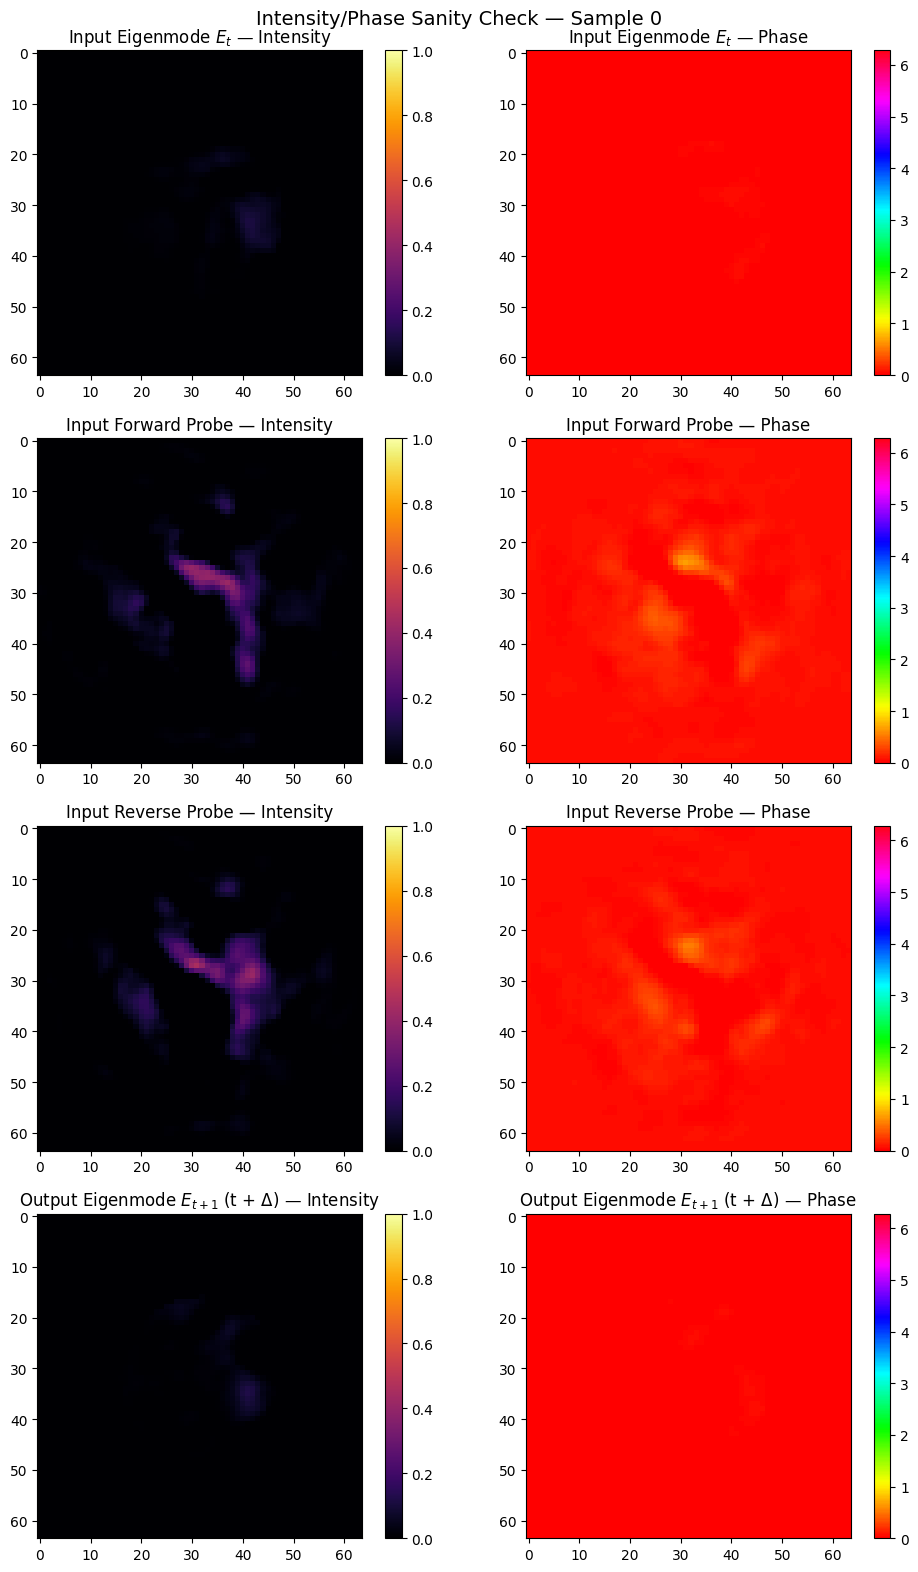

Eigenmode intensity range at t   : [-0.0873, 0.1094]  (expected within [0, 1])
Eigenmode phase range at t       : [-0.0670, 0.0706]  (expected within [0, 2*pi))
Eigenmode intensity range at t+1 : [-0.0969, 0.1218]
Eigenmode phase range at t+1     : [-0.0672, 0.0676]


In [79]:
check_index = 0   # ← row of X / Y to inspect

check_input  = X[check_index].numpy()   # (H, W, 6 or 11)
check_target = Y[check_index].numpy()   # (H, W, 2)  — [Δintensity, Δphase]

# Input channels (see prepare_pairs_delta docstring):
#   0,1 — eigenmode intensity (normalised [0,1]) / phase ([0, 2*pi)) at t
#   2,3 — forward probe intensity / phase at t
#   4,5 — reverse probe intensity / phase at t
in_em_intensity  = check_input[..., 0]
in_em_phase      = check_input[..., 1]
in_fwd_intensity = check_input[..., 2]
in_fwd_phase     = check_input[..., 3]
in_rev_intensity = check_input[..., 4]
in_rev_phase     = check_input[..., 5]

# Reconstruct the "output" eigenmode at t+1 = (t) + delta
out_em_intensity = in_em_intensity + check_target[..., 0]
out_em_phase     = in_em_phase + check_target[..., 1]

fig, axes = plt.subplots(4, 2, figsize=(10, 16))
fig.suptitle(f"Intensity/Phase Sanity Check — Sample {check_index}", fontsize=14)

rows = [
    ((in_em_intensity,  in_em_phase),  "Input Eigenmode $E_t$"),
    ((in_fwd_intensity, in_fwd_phase), "Input Forward Probe"),
    ((in_rev_intensity, in_rev_phase), "Input Reverse Probe"),
    ((out_em_intensity, out_em_phase), "Output Eigenmode $E_{t+1}$ (t + Δ)"),
]

for i, ((intensity, phase), title) in enumerate(rows):
    im_int = axes[i, 0].imshow(intensity, cmap='inferno', vmin=0, vmax=1)
    axes[i, 0].set_title(f"{title} — Intensity")
    plt.colorbar(im_int, ax=axes[i, 0])

    im_ph = axes[i, 1].imshow(phase, cmap='hsv', vmin=0, vmax=2 * np.pi)
    axes[i, 1].set_title(f"{title} — Phase")
    plt.colorbar(im_ph, ax=axes[i, 1])

plt.tight_layout()
plt.show()

print(f"Eigenmode intensity range at t   : [{in_em_intensity.min():.4f}, {in_em_intensity.max():.4f}]  (expected within [0, 1])")
print(f"Eigenmode phase range at t       : [{in_em_phase.min():.4f}, {in_em_phase.max():.4f}]  (expected within [0, 2*pi))")
print(f"Eigenmode intensity range at t+1 : [{out_em_intensity.min():.4f}, {out_em_intensity.max():.4f}]")
print(f"Eigenmode phase range at t+1     : [{out_em_phase.min():.4f}, {out_em_phase.max():.4f}]")


Prepare the dataset for training/test

In [92]:
n_total = int(1.0*X.shape[0])
n_train = int(0.85*n_total)
batch_size = 10

x_train =  X[:n_train]
x_test =  X[n_train:n_total]

y_train = Y[:n_train]
y_test = Y[n_train:n_total]

N = x_train.shape[2]

training_set = DataLoader(TensorDataset(x_train, y_train), batch_size=batch_size, shuffle=False)
testing_set = DataLoader(TensorDataset(x_test, y_test), batch_size=batch_size, shuffle=False)

I am curious. What does the distibution of overlaps look like between consective "frames", given that we work in the same eignemode? 

In [93]:
# --- Identity baseline and model fidelity over the full test set ---
# Note: testing_set yields (input, delta), so E_{t+1} must be reconstructed
# as E_t + ΔE before computing the overlap.

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device} ({torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'CPU'})")


identity_fidelities_train = []
identity_fidelities_test = []

#fno.eval()
eps = 1e-8

for input_batch, delta_batch in testing_set:

    input_batch = input_batch.to(device)   # (B, H, W, 6)
    delta_batch = delta_batch.to(device)   # (B, H, W, 2) — true ΔE

    em_t = input_batch[..., :2]  # eigenmode at t, (B, H, W, 2)

    # Reconstruct ground-truth E_{t+1} = E_t + ΔE_true
    output_batch = reconstruct_from_delta(em_t, delta_batch)          # (B, H, W, 2)

    #B_field      = torch.complex(output_batch[..., 0], output_batch[..., 1])  # (B, H, W)

    I_pred = torch.clamp(output_batch[..., 0], min=0.0)
    B_field = torch.sqrt(I_pred+eps)*torch.exp(1j*(2*np.pi*output_batch[..., 1]))
    norm_B_sq    = (B_field.abs() ** 2).sum(dim=(-2, -1))             # (B,)

    # ── Identity baseline: E_t  vs  E_{t+1} ──────────────────────────────

    I_em_t = torch.clamp(em_t[..., 0], min=0.0)
    A         = torch.sqrt(I_em_t + eps)*torch.exp(1j*2*np.pi*em_t[..., 1])     # (B, H, W)
    
    inner_id  = (A.conj() * B_field).sum(dim=(-2, -1))

    norm_A_sq = (A.abs() ** 2).sum(dim=(-2, -1))
    F_id      = inner_id.abs() ** 2 / (norm_A_sq * norm_B_sq + 1e-8)  # (B,)

    identity_fidelities_test.extend(F_id.cpu().tolist())


# Do the same for training

for input_batch, delta_batch in training_set:

    input_batch = input_batch.to(device)   # (B, H, W, 6)
    delta_batch = delta_batch.to(device)   # (B, H, W, 2) — true ΔE

    em_t = input_batch[..., :2]  # eigenmode at t, (B, H, W, 2)

    # Reconstruct ground-truth E_{t+1} = E_t + ΔE_true
    output_batch = reconstruct_from_delta(em_t, delta_batch)          # (B, H, W, 2)

    #B_field      = torch.complex(output_batch[..., 0], output_batch[..., 1])  # (B, H, W)

    I_pred = torch.clamp(output_batch[..., 0], min=0.0)
    B_field = torch.sqrt(I_pred+eps)*torch.exp(1j*(2*np.pi*output_batch[..., 1]))
    norm_B_sq    = (B_field.abs() ** 2).sum(dim=(-2, -1))             # (B,)

    # ── Identity baseline: E_t  vs  E_{t+1} ──────────────────────────────

    I_em_t = torch.clamp(em_t[..., 0], min=0.0)
    A         = torch.sqrt(I_em_t + eps)*torch.exp(1j*2*np.pi*em_t[..., 1])     # (B, H, W)
    
    inner_id  = (A.conj() * B_field).sum(dim=(-2, -1))

    norm_A_sq = (A.abs() ** 2).sum(dim=(-2, -1))
    F_id      = inner_id.abs() ** 2 / (norm_A_sq * norm_B_sq + 1e-8)  # (B,)

    identity_fidelities_train.extend(F_id.cpu().tolist())

identity_fidelities_test = np.array(identity_fidelities_test)
identity_fidelities_train = np.array(identity_fidelities_train)

print(f"Samples evaluated          : {len(identity_fidelities_test)} (Test), {len(identity_fidelities_train)} (Train)")
print(f"Identity baseline  — mean F : {identity_fidelities_test.mean():.4f}  |  std: {identity_fidelities_test.std():.4f}")
print(f"Model predictions  — mean F : {identity_fidelities_train.mean():.4f}  |  std: {identity_fidelities_train.std():.4f}")

Using device: cuda (NVIDIA GeForce RTX 5060 Laptop GPU)
Samples evaluated          : 477 (Test), 2702 (Train)
Identity baseline  — mean F : 0.0172  |  std: 0.0222
Model predictions  — mean F : 0.0167  |  std: 0.0222
Samples evaluated          : 477 (Test), 2702 (Train)
Identity baseline  — mean F : 0.0172  |  std: 0.0222
Model predictions  — mean F : 0.0167  |  std: 0.0222


Do the same, but using real and imaginary components again

In [83]:
# --- Identity baseline over the full test/train sets (Re/Im formulation) ---
# Note: testing_set / training_set yield (input, delta), so E_{t+1} must be
# reconstructed as E_t + ΔE before computing the overlap.
# Channels here are assumed [Re, Im], NOT [intensity, phase].

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device} ({torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'CPU'})")

identity_fidelities_train = []
identity_fidelities_test  = []

eps = 1e-8

for input_batch, delta_batch in testing_set:

    input_batch = input_batch.to(device)   # (B, H, W, 6)
    delta_batch = delta_batch.to(device)   # (B, H, W, 2) — true ΔE, [ΔRe, ΔIm]

    em_t = input_batch[..., :2]  # eigenmode at t, (B, H, W, 2) — [Re(t), Im(t)]

    # Reconstruct ground-truth E_{t+1} = E_t + ΔE_true
    output_batch = reconstruct_from_delta(em_t, delta_batch)   # (B, H, W, 2)

    # Direct complex construction — no sqrt/exp needed
    B_field   = torch.complex(output_batch[..., 0], output_batch[..., 1])  # (B, H, W)
    norm_B_sq = (B_field.abs() ** 2).sum(dim=(-2, -1))                     # (B,)

    # ── Identity baseline: E_t  vs  E_{t+1} ──────────────────────────────
    A = torch.complex(em_t[..., 0], em_t[..., 1])   # (B, H, W)

    inner_id  = (A.conj() * B_field).sum(dim=(-2, -1))
    norm_A_sq = (A.abs() ** 2).sum(dim=(-2, -1))
    F_id      = inner_id.abs() ** 2 / (norm_A_sq * norm_B_sq + eps)   # (B,)

    identity_fidelities_test.extend(F_id.cpu().tolist())


# Do the same for training
for input_batch, delta_batch in training_set:

    input_batch = input_batch.to(device)
    delta_batch = delta_batch.to(device)

    em_t = input_batch[..., :2]

    output_batch = reconstruct_from_delta(em_t, delta_batch)

    B_field   = torch.complex(output_batch[..., 0], output_batch[..., 1])
    norm_B_sq = (B_field.abs() ** 2).sum(dim=(-2, -1))

    A = torch.complex(em_t[..., 0], em_t[..., 1])

    inner_id  = (A.conj() * B_field).sum(dim=(-2, -1))
    norm_A_sq = (A.abs() ** 2).sum(dim=(-2, -1))
    F_id      = inner_id.abs() ** 2 / (norm_A_sq * norm_B_sq + eps)

    identity_fidelities_train.extend(F_id.cpu().tolist())

identity_fidelities_test  = np.array(identity_fidelities_test)
identity_fidelities_train = np.array(identity_fidelities_train)

print(f"Samples evaluated          : {len(identity_fidelities_test)} (Test), {len(identity_fidelities_train)} (Train)")
print(f"Identity baseline  — mean F : {identity_fidelities_test.mean():.4f}  |  std: {identity_fidelities_test.std():.4f}")
print(f"Model predictions  — mean F : {identity_fidelities_train.mean():.4f}  |  std: {identity_fidelities_train.std():.4f}")


Using device: cuda (NVIDIA GeForce RTX 5060 Laptop GPU)
Samples evaluated          : 1500 (Test), 8500 (Train)
Identity baseline  — mean F : 0.5152  |  std: 0.3805
Model predictions  — mean F : 0.5202  |  std: 0.3851


(array([804., 297., 207., 156., 113.,  88.,  91.,  74.,  57.,  35.,  55.,
         50.,  47.,  49.,  32.,  32.,  24.,  36.,  31.,  31.,  23.,  23.,
         23.,  27.,  17.,  20.,  25.,  21.,  11.,  13.,   6.,  14.,  11.,
         16.,  14.,  14.,   7.,  10.,  13.,   9.,   9.,  10.,   9.,   5.,
          8.,   9.,   8.,   9.,   5.,   4.]),
 array([6.30734064e-07, 1.99779825e-03, 3.99496577e-03, 5.99213329e-03,
        7.98930081e-03, 9.98646833e-03, 1.19836359e-02, 1.39808034e-02,
        1.59779709e-02, 1.79751384e-02, 1.99723059e-02, 2.19694734e-02,
        2.39666410e-02, 2.59638085e-02, 2.79609760e-02, 2.99581435e-02,
        3.19553110e-02, 3.39524786e-02, 3.59496461e-02, 3.79468136e-02,
        3.99439811e-02, 4.19411486e-02, 4.39383162e-02, 4.59354837e-02,
        4.79326512e-02, 4.99298187e-02, 5.19269862e-02, 5.39241538e-02,
        5.59213213e-02, 5.79184888e-02, 5.99156563e-02, 6.19128238e-02,
        6.39099914e-02, 6.59071589e-02, 6.79043264e-02, 6.99014939e-02,
        7.

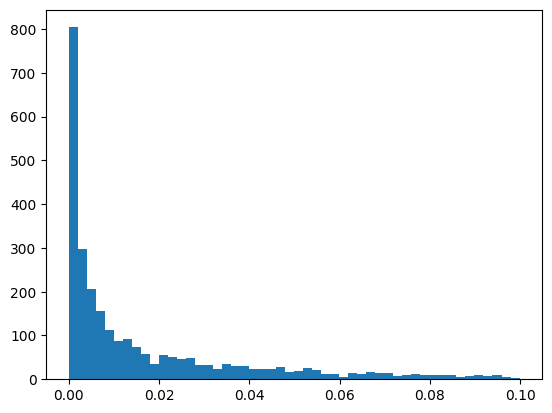

In [94]:
plt.hist(identity_fidelities_train, bins=50)

Instantiate the FNO architecture

In [95]:

epochs = 50

# These control the step-wise updates on the LR
learn_rate = 0.001  # initial LR
decay_rate = 0.001  # initial weight decay
step_size  = 12     # epochs between LR decay steps
gamma      = 0.5    # LR decay factor

# FNO architecture
modes1      = 36
modes2      = 36
width       = 32
n_layers    = 2
retrain_fno = 99

# 11-channel input:
#   0,1  : eigenmode Re/Im at t  (normalised)
#   2,3  : P→(t) Re/Im           current forward probe
#   4,5  : P←(t) Re/Im           current reverse probe
#   6,7  : P→(t-1) Re/Im         previous forward probe
#   8,9  : P←(t-1) Re/Im         previous reverse probe
#   10   : ΔI→(t)                 forward frame difference
input_chans  = 6
output_chans = 2

# Physical parameters
size     = 0.45     # simulation window (m)
lensSize = 0.1125   # size/4

fno_architecture = {"modes1": modes1, "modes2": modes2, "width": width, "n_layers": n_layers,
                    "retrain_fno": retrain_fno, "input_chans": input_chans, "output_chans": output_chans}


Load up GPU (if not already done so)

In [96]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print(f"Is CUDA available? {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU Name: {torch.cuda.get_device_name(0)}")

print(f"Using device: {device} ({torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'CPU'})")

Is CUDA available? True
GPU Name: NVIDIA GeForce RTX 5060 Laptop GPU
Using device: cuda (NVIDIA GeForce RTX 5060 Laptop GPU)


To avoid confusion, we apply an aperture on the output predicted channel. 

In [97]:
def torch_circ_aperture(field_batch: torch.Tensor, size: float, lensSize: float) -> torch.Tensor:
    """
    Applies a circular aperture to a batch of complex fields represented
    as real/imaginary channels.

    Parameters
    ----------
    field_batch : torch.Tensor  shape (batch, H, W, C)
                  where C=2 holds [real, imag] channels
    size        : float — physical side length of the window (metres)
    lensSize    : float — aperture radius (metres)

    Returns
    -------
    torch.Tensor — same shape as field_batch, zeroed outside the aperture
    """
    _, H, W, _ = field_batch.shape
    device = field_batch.device

    # Build physical coordinate axes centred at zero — same convention as LightPipes
    x = torch.linspace(-size / 2, size / 2, W, device=device)
    y = torch.linspace(-size / 2, size / 2, H, device=device)
    yy, xx = torch.meshgrid(y, x, indexing="ij")   # (H, W)

    # Binary mask: 1 inside aperture, 0 outside
    mask = (xx**2 + yy**2 <= lensSize**2).float()  # (H, W)
    mask = mask.unsqueeze(0).unsqueeze(-1)          # (1, H, W, 1) — broadcasts over batch and channels

    return field_batch * mask


Now train the FNO

In [98]:
from fno import overlap_loss_int_phase

use_mse_loss = False
use_overlap_loss = True

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device} ({torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'CPU'})")

# Instantiate the model and move to GPU
fno = FNO2d(fno_architecture, device=device)

optim = Adam(fno.parameters(), lr=learn_rate, weight_decay=1e-3)
scheduler = torch.optim.lr_scheduler.StepLR(optim, step_size=step_size, gamma=gamma)

if use_mse_loss:
    loss = torch.nn.MSELoss()
elif use_overlap_loss:
    loss = overlap_loss_int_phase
else:
    # Build a weight map once before the loop
    freq_weights = make_freq_weights(N, k_cutoff_frac=0.99, alpha=2.0, device=device)

freq_print = 1

n_train_batches = len(training_set)
n_test_batches = len(testing_set)

train_mse_history = []
test_rel_l2_history = []

for epoch in range(epochs):

    # Evaluate the training metric
    fno.train()
    train_mse = 0.0

    for step, (input_batch, delta_batch) in enumerate(training_set):
        input_batch = input_batch.to(device)   # (B, H, W, 6)
        delta_batch = delta_batch.to(device)   # (B, H, W, 2) — true ΔE

        optim.zero_grad()

        # Predict ΔE and apply aperture
        delta_pred_batch = torch_circ_aperture(fno(input_batch), size=size, lensSize=lensSize)  # (B, H, W, 2)

        # Reconstruct E_{t+1} = E_t + ΔE  (channels 0,1 of input are the eigenmode at t)
        output_pred_batch = reconstruct_from_delta(input_batch[..., :2], delta_pred_batch)   # (B, H, W, 2)
        output_batch      = reconstruct_from_delta(input_batch[..., :2], delta_batch)        # (B, H, W, 2)

        if use_mse_loss or use_overlap_loss:
            loss_f = loss(output_pred_batch, output_batch)
        else:
            loss_f = spectral_relative_l2(output_pred_batch, output_batch, freq_weights)

        loss_f.backward()
        optim.step()
        train_mse += loss_f.item()

    train_mse /= n_train_batches
    print("Training batches computed")

    scheduler.step()

    with torch.no_grad():
        fno.eval()
        test_relative_l2 = 0.0
        for step, (input_batch, delta_batch) in enumerate(testing_set):
            input_batch = input_batch.to(device)   # (B, H, W, 6)
            delta_batch = delta_batch.to(device)   # (B, H, W, 2) — true ΔE

            # Predict ΔE and apply aperture
            delta_pred_batch = torch_circ_aperture(fno(input_batch), size=size, lensSize=lensSize)  # (B, H, W, 2)

            # Reconstruct E_{t+1} = E_t + ΔE
            output_pred_batch = reconstruct_from_delta(input_batch[..., :2], delta_pred_batch)   # (B, H, W, 2)
            output_batch      = reconstruct_from_delta(input_batch[..., :2], delta_batch)        # (B, H, W, 2)

            if use_mse_loss:
                loss_f = (torch.mean((output_pred_batch - output_batch) ** 2) / torch.mean(output_batch ** 2)) ** 0.5 * 100
            elif use_overlap_loss:
                loss_f = loss(output_pred_batch, output_batch)
            else:
                loss_f = spectral_relative_l2(output_pred_batch, output_batch, freq_weights)

            test_relative_l2 += loss_f.item()

        test_relative_l2 /= n_test_batches

    train_mse_history.append(train_mse)
    test_rel_l2_history.append(test_relative_l2)

    if epoch % freq_print == 0:
        print(f"========= Epoch {epoch+1}/{epochs} Summary ========= Train Loss: {train_mse:.6f} | Mean Test Loss: {test_relative_l2:.4f}\n")


Using device: cuda (NVIDIA GeForce RTX 5060 Laptop GPU)
Training batches computed
Training batches computed
========= Epoch 1/50 Summary ========= Train Loss: 0.607612 | Mean Test Loss: 0.5715

========= Epoch 1/50 Summary ========= Train Loss: 0.607612 | Mean Test Loss: 0.5715

Training batches computed
Training batches computed
========= Epoch 2/50 Summary ========= Train Loss: 0.563488 | Mean Test Loss: 0.5526

========= Epoch 2/50 Summary ========= Train Loss: 0.563488 | Mean Test Loss: 0.5526

Training batches computed
Training batches computed
========= Epoch 3/50 Summary ========= Train Loss: 0.555547 | Mean Test Loss: 0.5466

========= Epoch 3/50 Summary ========= Train Loss: 0.555547 | Mean Test Loss: 0.5466

Training batches computed
Training batches computed
========= Epoch 4/50 Summary ========= Train Loss: 0.552315 | Mean Test Loss: 0.5444

========= Epoch 4/50 Summary ========= Train Loss: 0.552315 | Mean Test Loss: 0.5444

Training batches computed
Training batches compu

KeyboardInterrupt: 

Save the model (if applicable)

In [99]:

models_dir = "trained_models_eigen"
os.makedirs(models_dir, exist_ok=True)
model_path = os.path.join(models_dir, "fno_eigen.pth")

torch.save({
    "model_state_dict": fno.state_dict(),
    "optimizer_state_dict": optim.state_dict(),
    "fno_architecture": fno_architecture,
    "epochs": epochs,
    "train_mse_history": train_mse_history,
    "test_rel_l2_history": test_rel_l2_history,
}, model_path)

print(f"Model saved to {model_path}")

Model saved to trained_models_eigen\fno_eigen.pth


Make a plot

Plot saved to training_plots/training_curves.png


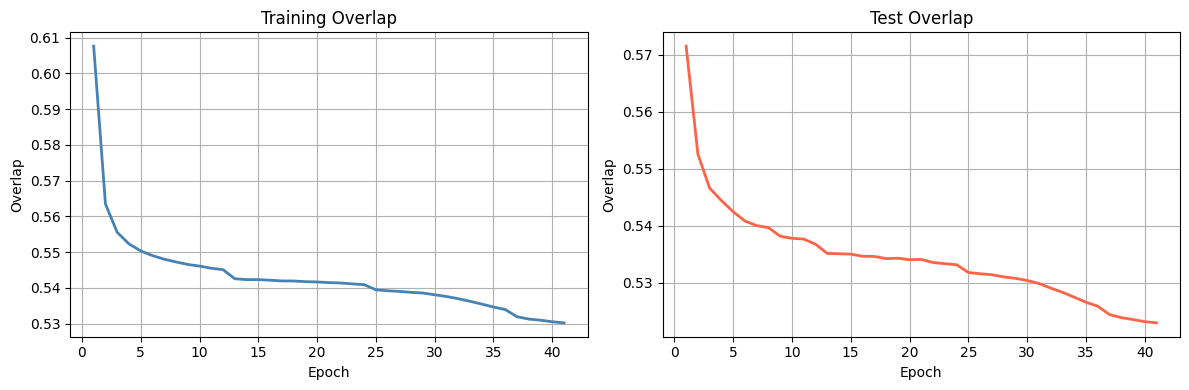

In [101]:
import os

epochs=epochs
epochs=41
epochs_range = range(1, epochs + 1)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(epochs_range, train_mse_history, color='steelblue', linewidth=2)
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Overlap")
axes[0].set_title("Training Overlap")
axes[0].grid(True)

axes[1].plot(epochs_range, test_rel_l2_history, color='tomato', linewidth=2)
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Overlap")
axes[1].set_title("Test Overlap")
axes[1].grid(True)

plt.tight_layout()

plots_dir = "training_plots"
os.makedirs(plots_dir, exist_ok=True)
fig.savefig(os.path.join(plots_dir, "training_curves.png"), dpi=150, bbox_inches="tight")
print(f"Plot saved to {plots_dir}/training_curves.png")

plt.show()

# Inference

How does our network do on infering the propagation of the network?

In [102]:
# Assign device (if applicable)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print(f"Is CUDA available? {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU Name: {torch.cuda.get_device_name(0)}")

print(f"Using device: {device} ({torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'CPU'})")

# Load the model checkpoint (if applicable)

checkpoint = torch.load("trained_models_eigen/fno_eigen.pth")
fno = FNO2d(checkpoint["fno_architecture"], device=device)
fno.load_state_dict(checkpoint["model_state_dict"])

sample_index = 50
input_sample = x_test[sample_index, :, :, :].unsqueeze(0).to(device)

# Extract the propagated field distance for reference

output_dist = input_sample[0,0,0,0]
print(output_dist)

fno.eval()
with torch.no_grad():
    output_pred = fno(input_sample)

# Reconstruct field from real and imaginary components

output_pred = output_pred.squeeze(0).cpu().numpy()
output_field = output_pred[..., 0] + 1j*output_pred[..., 1]

Is CUDA available? True
GPU Name: NVIDIA GeForce RTX 5060 Laptop GPU
Using device: cuda (NVIDIA GeForce RTX 5060 Laptop GPU)
tensor(0., device='cuda:0')


In [103]:
checkpoint["fno_architecture"]

{'modes1': 36,
 'modes2': 36,
 'width': 32,
 'n_layers': 2,
 'retrain_fno': 99,
 'input_chans': 6,
 'output_chans': 2}

Plot the input/output prediction

In [104]:

sample_index = 16
size = 0.45
lensSize = size / 4

# --- Run inference ---
input_sample = x_test[sample_index].unsqueeze(0).to(device)  # (1, H, W, 6)

fno.eval()
with torch.no_grad():
    # FNO predicts ΔE; apply aperture
    delta_pred = torch_circ_aperture(fno(input_sample), size=size, lensSize=lensSize)  # (1, H, W, 2)

# --- Extract eigenmode intensity/phase at t from input (channels 0, 1) ---
input_np           = x_test[sample_index].cpu().numpy()          # (H, W, 6 or 11)
eigenmode_in_i      = input_np[..., 0]                            # normalised intensity at t
eigenmode_in_p      = input_np[..., 1]                            # normalised phase at t
fwd_intensity_in    = input_np[..., 2]                            # forward probe intensity at t
fwd_phase_in        = input_np[..., 3]                            # forward probe phase at t

# --- Reconstruct true (intensity, phase) at t+1 = (t) + Δtrue ---
delta_true_np   = y_test[sample_index].cpu().numpy()          # (H, W, 2) — true [Δintensity, Δphase]
eigenmode_true_i = eigenmode_in_i + delta_true_np[..., 0]
eigenmode_true_p = eigenmode_in_p + delta_true_np[..., 1]

# --- Reconstruct predicted (intensity, phase) at t+1 = (t) + Δpred ---
delta_pred_np    = delta_pred.squeeze(0).cpu().numpy()         # (H, W, 2) — predicted [Δintensity, Δphase]
eigenmode_pred_i = eigenmode_in_i + delta_pred_np[..., 0]
eigenmode_pred_p = eigenmode_in_p + delta_pred_np[..., 1]

print(f"Input eigenmode intensity range  : [{eigenmode_in_i.min():.4f}, {eigenmode_in_i.max():.4f}]")
print(f"True output intensity range      : [{eigenmode_true_i.min():.4f}, {eigenmode_true_i.max():.4f}]")
print(f"Predicted output intensity range : [{eigenmode_pred_i.min():.4f}, {eigenmode_pred_i.max():.4f}]")


Input eigenmode intensity range  : [0.0000, 0.2668]
True output intensity range      : [0.0000, 0.2724]
Predicted output intensity range : [-0.0363, 0.7817]


Plot saved to inference_plots/inference_sample16.png


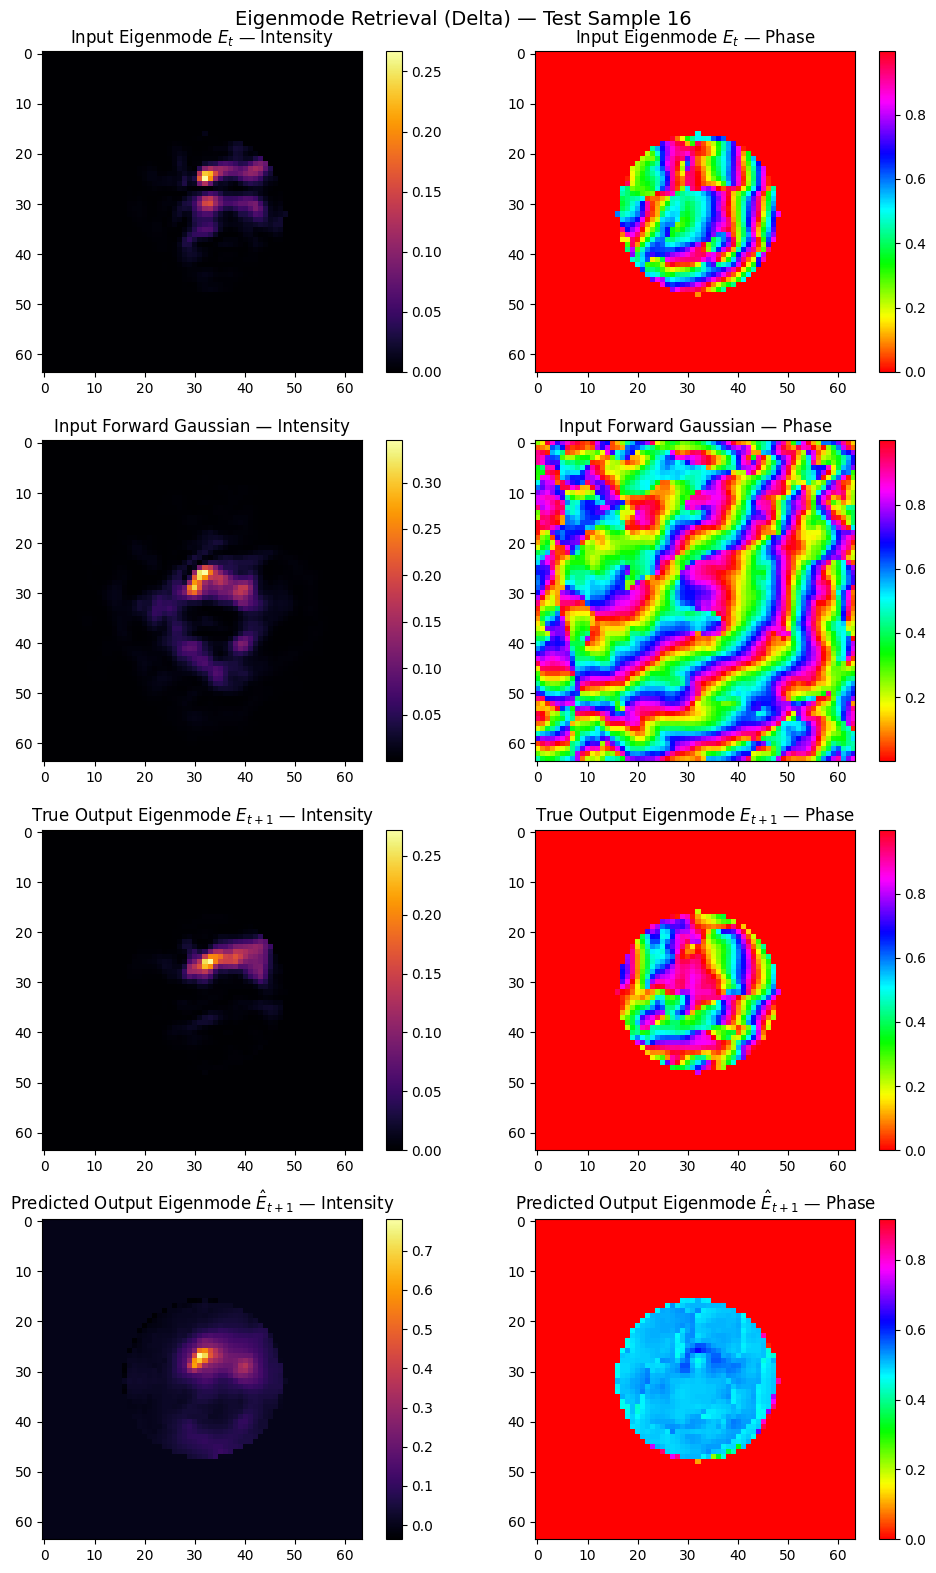

In [105]:

# --- Plot reconstructed fields ---
fig, axes = plt.subplots(4, 2, figsize=(10, 16))
fig.suptitle(f"Eigenmode Retrieval (Delta) — Test Sample {sample_index}", fontsize=14)

rows = [
    ((eigenmode_in_i,   eigenmode_in_p),   "Input Eigenmode $E_t$"),
    ((fwd_intensity_in, fwd_phase_in),     "Input Forward Gaussian"),
    ((eigenmode_true_i, eigenmode_true_p), "True Output Eigenmode $E_{t+1}$"),
    ((eigenmode_pred_i, eigenmode_pred_p), "Predicted Output Eigenmode $\\hat{E}_{t+1}$"),
]

for i, ((intensity, phase), title) in enumerate(rows):
    im_int = axes[i, 0].imshow(intensity, cmap='inferno')
    axes[i, 0].set_title(f"{title} — Intensity")
    plt.colorbar(im_int, ax=axes[i, 0])

    im_ph = axes[i, 1].imshow(phase, cmap='hsv')
    axes[i, 1].set_title(f"{title} — Phase")
    plt.colorbar(im_ph, ax=axes[i, 1])

plt.tight_layout()

plots_dir = "inference_plots"
os.makedirs(plots_dir, exist_ok=True)
fig.savefig(os.path.join(plots_dir, f"inference_sample{sample_index}.png"), dpi=150, bbox_inches="tight")
print(f"Plot saved to {plots_dir}/inference_sample{sample_index}.png")

plt.show()


Compute the "identity baseline." This entails taking the fidelities between the eigenmodes at consecutive timesteps. Do this with the dataset and with the model predictions.

In [52]:

# --- Identity baseline and model fidelity over the full test set ---
# Note: testing_set yields (input, delta), so E_{t+1} must be reconstructed
# as E_t + ΔE before computing the overlap.

identity_fidelities_test = []
identity_fidelities_pred = []

fno.eval()
eps = 1e-8

with torch.no_grad():
    for input_batch, delta_batch in testing_set:

        input_batch = input_batch.to(device)   # (B, H, W, 6)
        delta_batch = delta_batch.to(device)   # (B, H, W, 2) — true ΔE

        em_t = input_batch[..., :2]  # eigenmode at t, (B, H, W, 2)

        # Reconstruct ground-truth E_{t+1} = E_t + ΔE_true
        output_batch = reconstruct_from_delta(em_t, delta_batch)          # (B, H, W, 2)

        #B_field      = torch.complex(output_batch[..., 0], output_batch[..., 1])  # (B, H, W)

        I_pred = torch.clamp(output_batch[..., 0], min=0.0)
        B_field = torch.sqrt(I_pred+eps)*torch.exp(1j*(2*np.pi*output_batch[..., 1]))
        norm_B_sq    = (B_field.abs() ** 2).sum(dim=(-2, -1))             # (B,)

        # ── Identity baseline: E_t  vs  E_{t+1} ──────────────────────────────

        I_em_t = torch.clamp(em_t[..., 0], min=0.0)
        A         = torch.sqrt(I_em_t + eps)*torch.exp(1j*2*np.pi*em_t[..., 1])     # (B, H, W)
        
        inner_id  = (A.conj() * B_field).sum(dim=(-2, -1))

        norm_A_sq = (A.abs() ** 2).sum(dim=(-2, -1))
        F_id      = inner_id.abs() ** 2 / (norm_A_sq * norm_B_sq + 1e-8)  # (B,)

        identity_fidelities_test.extend(F_id.cpu().tolist())

        # ── Model: reconstruct Ê_{t+1} = E_t + ΔE_pred ───────────────────────
        delta_pred_batch  = torch_circ_aperture(fno(input_batch), size=size, lensSize=lensSize)
        output_pred_batch = reconstruct_from_delta(em_t, delta_pred_batch)  # (B, H, W, 2)
        
        I_output_pred = torch.clamp(output_pred_batch[..., 0], min=0.0)
        C         = torch.sqrt(I_output_pred + eps)*torch.exp(1j*2*np.pi*output_pred_batch[..., 1])  # (B, H, W)

        inner_pred = (C.conj() * B_field).sum(dim=(-2, -1))
        norm_C_sq  = (C.abs() ** 2).sum(dim=(-2, -1))
        F_pred     = inner_pred.abs() ** 2 / (norm_C_sq * norm_B_sq + 1e-8)  # (B,)
        identity_fidelities_pred.extend(F_pred.cpu().tolist())

identity_fidelities_test = np.array(identity_fidelities_test)
identity_fidelities_pred = np.array(identity_fidelities_pred)

print(f"Samples evaluated          : {len(identity_fidelities_test)}")
print(f"Identity baseline  — mean F : {identity_fidelities_test.mean():.4f}  |  std: {identity_fidelities_test.std():.4f}")
print(f"Model predictions  — mean F : {identity_fidelities_pred.mean():.4f}  |  std: {identity_fidelities_pred.std():.4f}")


Samples evaluated          : 750
Identity baseline  — mean F : 0.5174  |  std: 0.3880
Model predictions  — mean F : 0.0970  |  std: 0.1014


(array([172.,  30.,  22.,   9.,  10.,   8.,   8.,   5.,   1.,   6.,   4.,
          1.,   4.,   1.,   1.,   4.,   1.,   1.,   3.,   1.,   1.,   1.,
          1.,   1.,   4.,   4.,   2.,   5.,   3.,   3.,   3.,   3.,  11.,
          8.,   5.,  10.,  13.,  19.,  11.,  18.,  18.,  32.,  31.,  34.,
         45.,  46.,  44.,  49.,  23.,  10.]),
 array([1.41906764e-06, 1.94393570e-02, 3.88772950e-02, 5.83152330e-02,
        7.77531709e-02, 9.71911089e-02, 1.16629047e-01, 1.36066985e-01,
        1.55504923e-01, 1.74942861e-01, 1.94380799e-01, 2.13818737e-01,
        2.33256675e-01, 2.52694613e-01, 2.72132551e-01, 2.91570489e-01,
        3.11008427e-01, 3.30446364e-01, 3.49884302e-01, 3.69322240e-01,
        3.88760178e-01, 4.08198116e-01, 4.27636054e-01, 4.47073992e-01,
        4.66511930e-01, 4.85949868e-01, 5.05387806e-01, 5.24825744e-01,
        5.44263682e-01, 5.63701620e-01, 5.83139558e-01, 6.02577496e-01,
        6.22015434e-01, 6.41453372e-01, 6.60891310e-01, 6.80329248e-01,
        6.

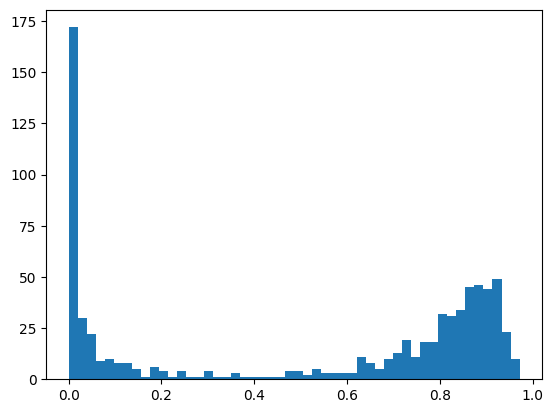

In [53]:
plt.hist(identity_fidelities_test, bins=50)